# Home Credit Default Risk — Predicting Loan Repayment

**Competition:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle)

**Objective:** Predict whether a borrower will default on their loan, based on application data (307,000+ loans). This is a binary classification task evaluated with **AUC-ROC** (Area Under the ROC Curve).

**Business context:** Home Credit provides loans to people with little or no credit history. An accurate default prediction model helps the company reduce losses while extending credit to underserved populations.

**Pipeline:**
1. Exploratory Data Analysis
2. Preprocessing (encoding, missing values, imputation)
3. Correlation analysis
4. Modeling — Logistic Regression → Random Forest → XGBoost
5. Model comparison (ROC curves, AUC)
6. Feature importance analysis

## 1. Setup & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df_train = pd.read_csv('/Users/etoh/Desktop/home-credit-default-risk/application_train.csv')
df_test = pd.read_csv('/Users/etoh/Desktop/home-credit-default-risk/application_test.csv')

## 2. Exploratory Data Analysis

Before building any model, we need to understand the data: how many rows/columns ? what the target looks like ? how much data is missing ? 

In [24]:
df_train.shape

(307511, 122)

In [25]:
df_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


### Target distribution

The target variable indicates whether a client defaulted (1) or repaid on time (0). We expect a strong class imbalance — most loans are repaid.

(array([282686.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  24825.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

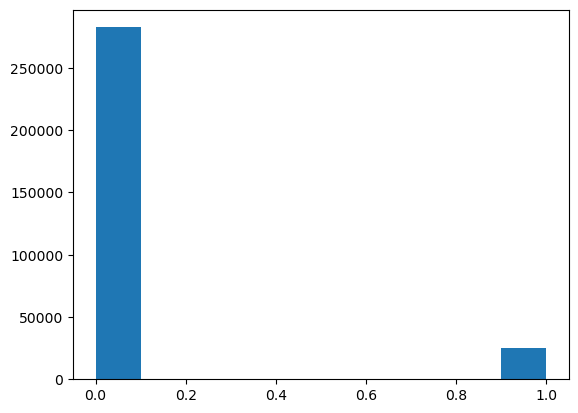

In [26]:
plt.hist(df_train['TARGET'])

In [27]:
df_train['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

## 3. Missing Values Analysis

Many features have missing values. We inspect the percentage of missing data per column to decide which columns to keep and which to drop.

In [28]:
# Valeurs manquantes : nombre et pourcentage, triés
missing = df_train.isnull().sum()
missing_pct = missing / len(df_train) * 100

pd.DataFrame({'missing': missing, 'pct': missing_pct}).sort_values(by='pct', ascending=False)

,missing,pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
...,...,...
NAME_HOUSING_TYPE,0,0.000000
NAME_FAMILY_STATUS,0,0.000000
NAME_EDUCATION_TYPE,0,0.000000
NAME_INCOME_TYPE,0,0.000000


In [29]:
print("df_train :\n",df_train.dtypes.value_counts())
print()
print("df_test :\n",df_test.dtypes.value_counts())


df_train :
 float64    65
int64      41
object     16
Name: count, dtype: int64

df_test :
 float64    65
int64      40
object     16
Name: count, dtype: int64


## 4. Preprocessing

Three steps: encode categorical variables, remove columns with too many missing values, and impute the rest with the median.

### 4.1 One-Hot Encoding

We convert all categorical (text) columns into binary 0/1 columns. We then align train and test sets to ensure they have the same columns.

In [30]:
# Convertit toutes les colonnes texte en colonnes 0/1
df_train = pd.get_dummies(df_train)
df_test  = pd.get_dummies(df_test)

# Train et test doivent avoir les mêmes colonnes
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

print("df_train :", df_train.shape)
print("df_test  :", df_test.shape)

df_train : (307511, 246)
df_test  : (48744, 246)


### 4.2 Dropping columns with >50% missing values

Columns where more than half the values are missing carry too little information — we remove them from both train and test.

In [31]:
# Colonnes à supprimer : plus de 50% de valeurs manquantes
cols_to_drop = df_train.isnull().mean()[df_train.isnull().mean() > 0.5].index

df_train = df_train.drop(columns=cols_to_drop)
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes supprimées : {len(cols_to_drop)}")
print(f"df_train : {df_train.shape}")


Colonnes supprimées : 38
df_train : (307511, 208)


### 4.3 Median imputation

For the remaining missing values, we fill them with the **median of the training set**. Using the train median (not test) prevents data leakage.

In [32]:
train_median = df_train.median()

df_train = df_train.fillna(train_median)
df_test  = df_test.fillna(train_median)

print("Valeurs manquantes restantes :", df_train.isnull().sum().sum())

Valeurs manquantes restantes : 0


## 5. Correlation Analysis

We look at which features are most correlated with the target variable. This gives a first indication of which variables might be predictive.

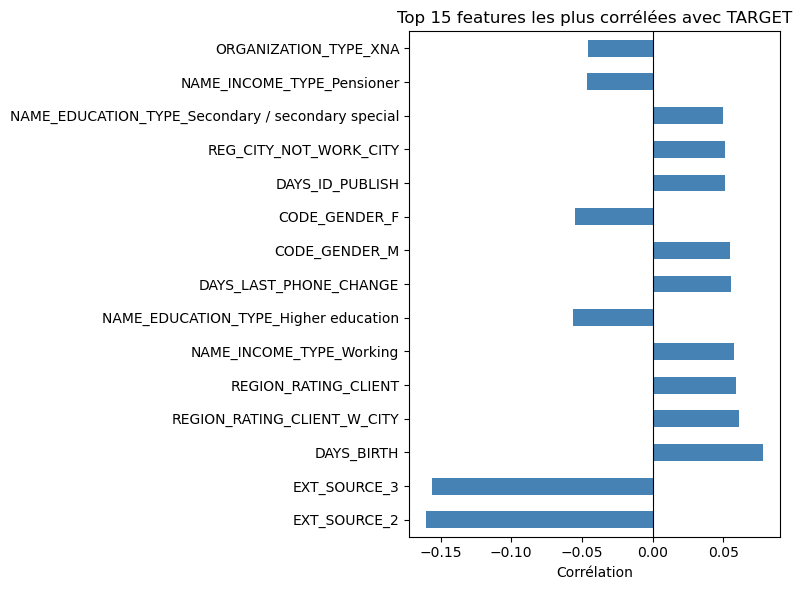

In [33]:
# Corrélation de chaque feature avec TARGET, triée par valeur absolue
correlations = df_train.corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

# Top 15 features les plus corrélées
correlations.head(15).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 15 features les plus corrélées avec TARGET')
plt.xlabel('Corrélation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Modeling

We train three models of increasing complexity and compare their performance on a held-out validation set (20% of the training data).

- **Logistic Regression** — simple linear baseline
- **Random Forest** — ensemble of independent decision trees
- **XGBoost** — gradient boosting (each tree corrects the previous one)

### 6.1 Logistic Regression (baseline)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# Séparation features / cible
X = df_train.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_train['TARGET']

# Split train / validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation (même logique : scaler fitté sur le train uniquement)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Entraînement
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Évaluation
y_pred = model_lr.predict_proba(X_val)[:, 1]

auc_lr = roc_auc_score(y_val, y_pred)
print(f"AUC Logistic Regression : {auc_lr:.3f}")

AUC Logistic Regression : 0.743


### 6.2 Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest : pas besoin de normaliser les données
# On ré-utilise X, y (avant normalisation) et le même split
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entraînement (100 arbres, profondeur limitée pour éviter l'overfitting)
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_rf, y_train_rf)

# Prédictions (probabilités)
y_pred_rf = model_rf.predict_proba(X_val_rf)[:, 1]

# AUC
auc_rf = roc_auc_score(y_val_rf, y_pred_rf)
print(f"AUC Random Forest : {auc_rf:.3f}")

AUC Random Forest : 0.734


### 6.3 XGBoost

In [36]:
from xgboost import XGBClassifier

# XGBoost : même split, pas besoin de normaliser
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entraînement
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
model_xgb.fit(X_train_xgb, y_train_xgb)

# Prédictions (probabilités)
y_pred_xgb = model_xgb.predict_proba(X_val_xgb)[:, 1]

# AUC
auc_xgb = roc_auc_score(y_val_xgb, y_pred_xgb)
print(f"AUC XGBoost : {auc_xgb:.3f}")

AUC XGBoost : 0.753


## 7. Model Comparison

We plot the ROC curves of all three models on the same graph. The closer a curve is to the top-left corner, the better the model separates defaulters from non-defaulters.

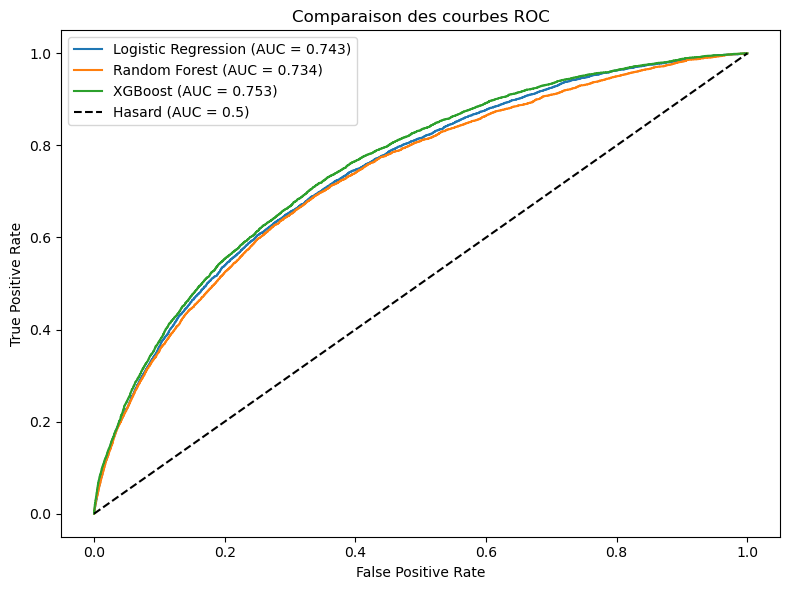


--- Résumé ---
Logistic Regression : AUC = 0.743
Random Forest       : AUC = 0.734
XGBoost             : AUC = 0.753


In [37]:
# Courbes ROC des 3 modèles sur le même graphique
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred)
auc_lr = roc_auc_score(y_val, y_pred)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_val_rf, y_pred_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_val_xgb, y_pred_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Ligne du hasard (modèle qui ne sait rien)
plt.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparaison des courbes ROC')
plt.legend()
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n--- Résumé ---")
print(f"Logistic Regression : AUC = {auc_lr:.3f}")
print(f"Random Forest       : AUC = {auc_rf:.3f}")
print(f"XGBoost             : AUC = {auc_xgb:.3f}")

## 8. Feature Importance

Which variables matter most? We compare feature importance across all three models. If the same variables appear at the top for every model, it means those signals are robust and not an artifact of a single algorithm.

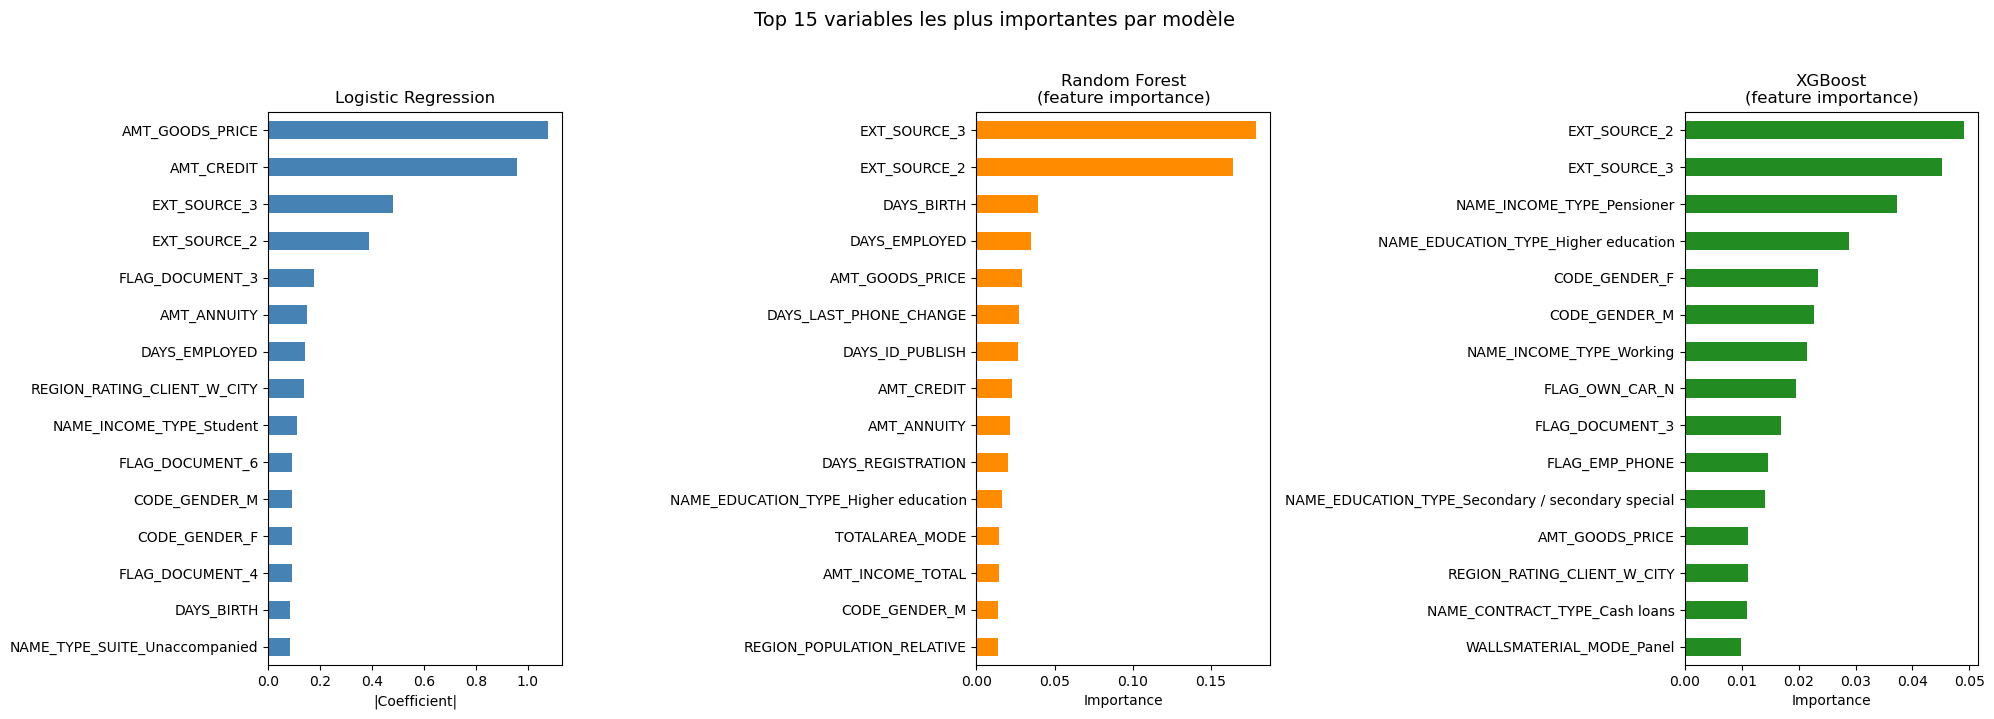

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Logistic Regression ---
# Pour LR, l'importance = valeur absolue des coefficients
coefs = pd.Series(
    np.abs(model_lr.coef_[0]),
    index=X.columns
).sort_values(ascending=False).head(15)

coefs.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('|Coefficient|')

# --- Random Forest ---
rf_imp = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

rf_imp.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Random Forest\n(feature importance)')
axes[1].set_xlabel('Importance')

# --- XGBoost ---
xgb_imp = pd.Series(
    model_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

xgb_imp.sort_values().plot(kind='barh', ax=axes[2], color='forestgreen')
axes[2].set_title('XGBoost\n(feature importance)')
axes[2].set_xlabel('Importance')

plt.suptitle('Top 15 variables les plus importantes par modèle', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Conclusion

### Results

XGBoost achieves the best AUC-ROC score, which is expected — gradient boosting methods are known to be the strongest approach for structured tabular data.

However, it is important to note that, in certain machine learning applications, one might prefer to use a model that is slightly less predictive but more interpretable, such as logistic regression for example.

### Key findings

- The most predictive features across all three models are **EXT_SOURCE_2, EXT_SOURCE_3** (external credit scores), **DAYS_BIRTH** (client age), and **AMT_CREDIT** (loan amount). These variables have a clear economic interpretation: older clients and those with a strong external credit history are less likely to default.
- The dataset is **highly imbalanced** (~92% non-default vs ~8% default), which makes AUC-ROC a better evaluation metric than simple accuracy.
- Using only the main application table already gives reasonable results.

### Possible improvements

- **Feature engineering:** join auxiliary tables to enrich client profiles with credit history and past loan behavior
- **Hyperparameter tuning:** use cross-validation to find optimal model parameters